In [6]:
! pip install pandas openpyxl seaborn matplotlib ydata-profiling



   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 2.9 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.0 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.0 MB 3.1 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.0 MB 3.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.0 MB 3.6 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/11.0 MB 3.7 MB/s eta 0:00:02
   -------------------- ------------------- 5.5/11.0 MB 3.8 MB/s eta 0:00:02
   ----------------------- ---------------- 6.6/11.0 MB 3.9 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.0 MB 3.8 MB/s eta 0:00:02
   ---------------------------- ----------- 7.9/11.0 MB 3.8 MB/s eta 0:00:01
   ------------------------------- -------- 8.7/11.0 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 3.8 MB/s eta 0:00:01
   ---

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# UNDERSTANDING DATA

### READING DATA

In [8]:
df=pd.read_excel('data.xlsx')


### HOW BIG IS THE DATA?


In [9]:
df.shape

(500, 21)

### OVERVIEW OF DATA

In [10]:
df.head()

,ID,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,...,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
0,1,10.0,43.2,6.7,50.1,4.3,0.7,5.0,2.77,7.3,...,87.7,26.3,30.1,35.3,11.4,189.0,9.2,12.5,0.17,22.3
1,2,10.0,42.4,5.3,52.3,4.2,0.5,5.3,2.84,7.3,...,88.2,25.7,20.2,35.3,11.4,180.0,8.9,12.5,0.16,19.5
2,3,7.2,30.7,8.6,60.7,2.2,0.6,4.4,3.97,9.0,...,77.0,22.6,29.5,37.2,13.7,148.0,10.1,14.3,0.14,30.5
3,4,6.0,30.2,6.3,63.5,1.8,0.4,3.8,4.22,3.8,...,77.9,23.2,29.8,46.5,17.0,143.0,8.6,11.3,0.12,16.4
4,5,4.2,39.1,7.2,53.7,1.6,0.3,2.3,3.93,0.4,...,80.6,23.9,29.7,42.7,15.1,236.0,19.5,12.8,0.22,24.8


In [11]:
df=df.iloc[:,1:]

### SELECTING REQUIRED COLUMNS

### DATATYPES OF COLUMNS

In [12]:
df.dtypes

WBC      float64
LYMp     float64
MIDp     float64
NEUTp    float64
LYMn     float64
MIDn     float64
NEUTn    float64
RBC      float64
HGB      float64
HCT      float64
MCV      float64
MCH      float64
MCHC     float64
RDWSD    float64
RDWCV    float64
PLT      float64
MPV      float64
PDW      float64
PCT      float64
PLCR     float64
dtype: object

### RANDOM SAMPLE OF DATA

In [13]:
df.sample(10)

,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
217,12.3,20.7,8.1,71.2,2.6,1.0,8.7,2.26,16.5,50.2,86.9,28.5,32.8,39.0,12.8,190.0,9.9,14.1,0.18,27.6
439,8.5,19.6,8.9,71.5,1.7,0.8,6.0,3.59,8.7,28.5,79.5,24.2,30.5,37.2,13.3,122.0,8.6,11.3,0.10,18.4
165,6.8,22.6,8.1,69.3,1.5,0.6,4.7,4.24,11.7,38.1,90.0,27.5,30.7,37.2,11.7,192.0,9.6,12.5,0.18,24.0
327,4.5,25.8,9.8,64.4,1.2,0.4,2.9,4.13,10.5,34.3,83.2,25.4,30.6,31.6,10.8,128.0,9.7,12.8,0.12,25.6
344,3.2,43.5,7.4,49.1,1.4,0.2,1.6,5.12,11.9,40.6,-79.3,23.2,29.3,39.0,14.0,161.0,10.8,15.9,0.17,35.6
192,5.5,26.7,6.7,66.6,1.5,0.4,3.6,3.66,6.3,24.7,67.6,17.2,25.5,35.3,14.9,195.0,8.9,14.1,0.17,21.7
383,6.1,24.1,8.8,671.0,5.1,0.5,4.1,5.53,14.4,46.1,83.5,26.0,31.2,37.2,15.1,151.0,10.2,15.1,0.15,29.7
385,5.7,33.6,6.7,59.7,1.9,0.4,3.4,5.07,14.6,44.7,88.3,28.7,32.6,37.2,12.0,120.0,9.4,11.8,0.11,22.0
355,4.2,9.5,5.8,84.7,0.4,0.2,3.6,3.34,9.2,28.4,85.3,27.5,32.3,39.0,13.0,107.0,9.7,13.1,0.10,26.7
152,13.0,14.3,8.1,77.6,1.9,1.1,10.0,3.81,9.3,31.5,82.7,24.4,29.5,35.3,12.1,241.0,9.8,14.6,0.23,27.1


### INFO ABOUT DATA

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   WBC     500 non-null    float64
 1   LYMp    500 non-null    float64
 2   MIDp    500 non-null    float64
 3   NEUTp   500 non-null    float64
 4   LYMn    500 non-null    float64
 5   MIDn    500 non-null    float64
 6   NEUTn   500 non-null    float64
 7   RBC     500 non-null    float64
 8   HGB     500 non-null    float64
 9   HCT     500 non-null    float64
 10  MCV     500 non-null    float64
 11  MCH     500 non-null    float64
 12  MCHC    500 non-null    float64
 13  RDWSD   500 non-null    float64
 14  RDWCV   500 non-null    float64
 15  PLT     500 non-null    float64
 16  MPV     500 non-null    float64
 17  PDW     500 non-null    float64
 18  PCT     500 non-null    float64
 19  PLCR    500 non-null    float64
dtypes: float64(20)
memory usage: 78.3 KB


### ARE THERE ANY MISSING VALUES?

In [15]:
df.isnull().sum()

WBC      0
LYMp     0
MIDp     0
NEUTp    0
LYMn     0
MIDn     0
NEUTn    0
RBC      0
HGB      0
HCT      0
MCV      0
MCH      0
MCHC     0
RDWSD    0
RDWCV    0
PLT      0
MPV      0
PDW      0
PCT      0
PLCR     0
dtype: int64

### MATHEMATICAL INFO ABOUT THE DATA

In [16]:
df.describe()

,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
count,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,7.371800,25.845000,8.69262,77.511000,1.880760,0.672080,5.140940,4.882860,11.740020,46.15260,82.181380,37.45600,30.950820,38.078220,13.65478,171.221800,12.873020,13.727200,0.260280,26.292020
std,3.704331,11.273243,6.95864,236.630786,2.139243,0.826036,4.600272,4.403204,5.628807,167.98583,42.318848,177.87964,4.577839,18.791718,6.08067,61.669883,43.040472,4.347798,1.097659,7.145895
min,0.800000,6.200000,0.50000,0.700000,0.200000,0.100000,0.500000,1.420000,-10.000000,2.00000,-79.300000,10.90000,11.500000,7.200000,8.90000,11.300000,0.140000,8.400000,0.010000,0.120000
25%,5.100000,17.000000,6.90000,58.875000,1.200000,0.400000,3.100000,4.240000,9.900000,32.97500,76.575000,23.17500,29.700000,35.300000,12.20000,135.000000,9.200000,12.000000,0.130000,21.375000
50%,6.700000,24.800000,7.80000,66.950000,1.600000,0.500000,4.400000,4.590000,11.500000,37.10000,82.800000,25.70000,30.900000,37.200000,12.70000,163.500000,9.700000,13.300000,0.150000,26.100000
75%,8.700000,32.725000,8.90000,73.925000,2.100000,0.700000,6.000000,5.010000,13.100000,41.00000,86.500000,27.42500,31.900000,39.000000,13.70000,197.250000,10.200000,14.900000,0.190000,30.600000
max,45.700000,91.400000,77.00000,5317.000000,41.800000,10.000000,79.000000,90.800000,87.100000,3715.00000,990.000000,3117.00000,92.800000,390.000000,124.00000,508.000000,919.000000,97.000000,13.600000,48.500000


### ARE THERE ANY DUPLICATED VALUES?

In [17]:
df.duplicated().sum()

np.int64(3)

### ARE THERE ANY NEGATIVE VALUES?

In [18]:
(df<0).sum()

WBC      0
LYMp     0
MIDp     0
NEUTp    0
LYMn     0
MIDn     0
NEUTn    0
RBC      0
HGB      1
HCT      0
MCV      1
MCH      0
MCHC     0
RDWSD    0
RDWCV    0
PLT      0
MPV      0
PDW      0
PCT      0
PLCR     0
dtype: int64

### CORRELATION BETWEEN THE COULUMNS

##### (0,1] → directly proportional correlation

##### 0 → no relationship

##### [-1,0) → inversely proportional correlation

In [19]:
df.corr()

,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
WBC,1.000000,-0.152087,0.071025,-0.035442,0.585589,0.326674,0.471919,0.038163,0.074028,-0.003527,-0.035445,-0.016107,-0.053456,0.056893,0.001191,0.225108,-0.050488,-0.050500,-0.006494,-0.102854
LYMp,-0.152087,1.000000,-0.106783,0.009017,0.465271,-0.205522,-0.296009,-0.032130,-0.013166,0.019576,-0.015872,-0.005449,-0.074760,-0.021859,0.003895,0.115167,-0.042864,0.012968,-0.038542,0.098703
MIDp,0.071025,-0.106783,1.000000,-0.011054,-0.045614,0.088369,0.039410,0.090575,0.186162,-0.014981,-0.037442,-0.006381,-0.101957,0.153855,-0.001092,-0.048503,0.000691,-0.013803,-0.002044,0.039916
NEUTp,-0.035442,0.009017,-0.011054,1.000000,-0.019970,-0.016641,-0.015514,-0.015749,-0.027279,-0.004367,0.000013,-0.003423,-0.005018,0.005375,0.012120,0.039440,-0.001863,-0.009319,-0.000491,-0.012417
LYMn,0.585589,0.465271,-0.045614,-0.019970,1.000000,0.035422,0.047662,0.013589,0.017524,0.003046,-0.024780,-0.009659,-0.078023,0.021843,0.003299,0.175439,-0.032853,-0.015965,-0.019014,0.018774
MIDn,0.326674,-0.205522,0.088369,-0.016641,0.035422,1.000000,0.184237,0.382811,0.220582,-0.017191,-0.047237,0.007216,-0.088229,0.121356,0.078642,-0.095724,0.066312,0.007464,0.310875,-0.103161
NEUTn,0.471919,-0.296009,0.039410,-0.015514,0.047662,0.184237,1.000000,0.029994,0.088600,0.091813,-0.014511,0.047547,-0.018382,0.036730,-0.012079,0.053691,-0.040167,-0.042743,-0.043049,-0.101091
RBC,0.038163,-0.032130,0.090575,-0.015749,0.013589,0.382811,0.029994,1.000000,0.447023,-0.000836,-0.039127,-0.011425,-0.102090,0.199427,-0.025935,-0.106731,-0.017352,0.041590,-0.013834,-0.001547
HGB,0.074028,-0.013166,0.186162,-0.027279,0.017524,0.220582,0.088600,0.447023,1.000000,-0.000498,-0.017746,0.001929,-0.112565,0.405335,-0.078176,-0.239498,-0.030430,0.133781,-0.057841,0.055727
HCT,-0.003527,0.019576,-0.014981,-0.004367,0.003046,-0.017191,0.091813,-0.000836,-0.000498,1.000000,0.000837,0.608604,0.002384,-0.015628,-0.018391,-0.043227,-0.003715,0.098386,-0.012773,0.093244


# Exploratory Data Analysis (EDA)

## UNIVARIATE ANALYSIS

In [20]:
df.sample()

,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR
249,4.1,12.1,7.5,30.4,0.5,0.13,3.3,4.35,10.6,35.0,80.6,24.3,30.2,39.0,13.8,157.0,9.8,12.8,0.15,26.4


### Mean Corpuscular Volume (MCV)

In [21]:
df['MCV'].describe()

count    500.000000
mean      82.181380
std       42.318848
min      -79.300000
25%       76.575000
50%       82.800000
75%       86.500000
max      990.000000
Name: MCV, dtype: float64

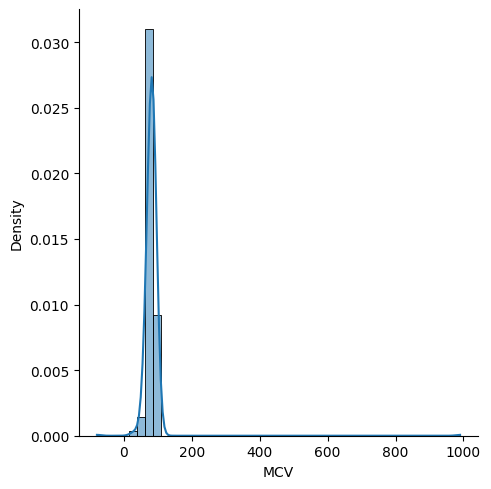

In [22]:
sns.displot(df['MCV'], kde=True,stat='density')

<Axes: xlabel='MCV'>

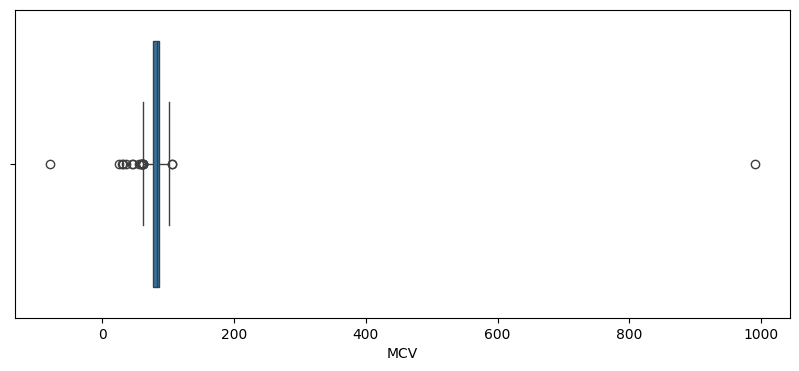

In [23]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['MCV'])

### Mean Corpuscular Hemoglobin (MCH)

In [24]:
df['MCH'].describe()

count     500.00000
mean       37.45600
std       177.87964
min        10.90000
25%        23.17500
50%        25.70000
75%        27.42500
max      3117.00000
Name: MCH, dtype: float64

<Axes: xlabel='MCH', ylabel='Count'>

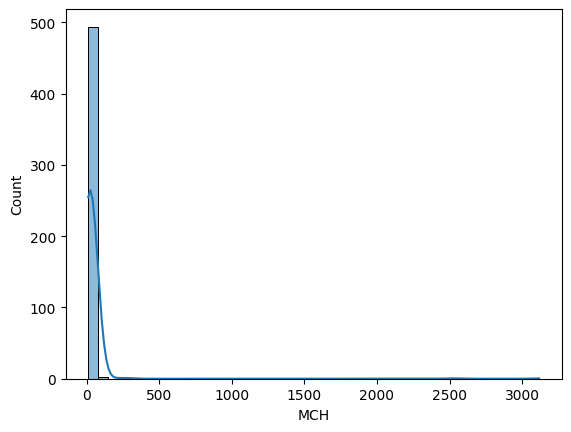

In [25]:
sns.histplot(x='MCH',data=df,kde=True)

<Axes: xlabel='MCH'>

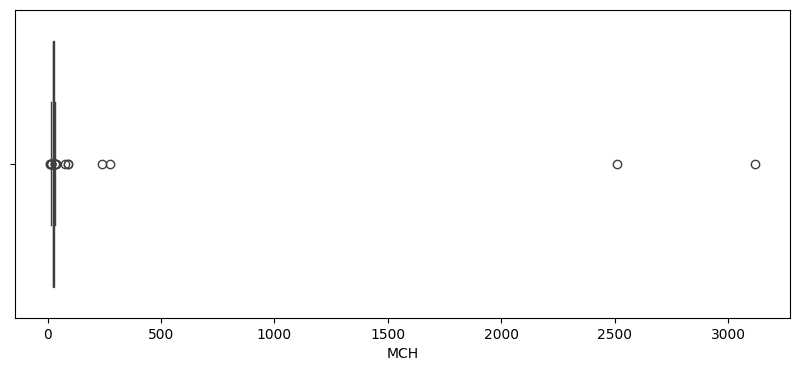

In [26]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['MCH'])

### Mean Corpuscular Hemoglobin Concentration (MCHC) 

In [27]:
df['MCHC'].describe()

count    500.000000
mean      30.950820
std        4.577839
min       11.500000
25%       29.700000
50%       30.900000
75%       31.900000
max       92.800000
Name: MCHC, dtype: float64

<Axes: xlabel='MCHC', ylabel='Count'>

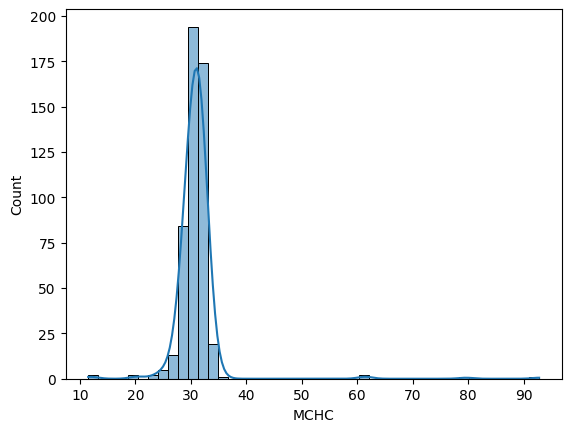

In [28]:
sns.histplot(x='MCHC',data=df,kde=True)

<Axes: xlabel='MCHC'>

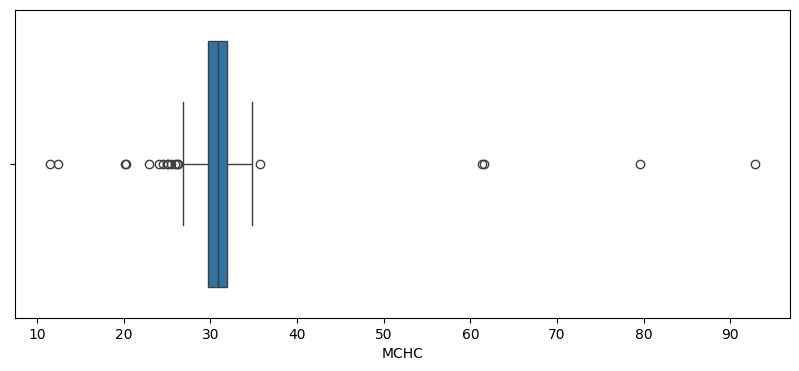

In [29]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['MCHC'])

### Red Cell Distribution Width (Coefficient of Variation), RDW-CV

In [30]:
df['RDWCV'].describe()

count    500.00000
mean      13.65478
std        6.08067
min        8.90000
25%       12.20000
50%       12.70000
75%       13.70000
max      124.00000
Name: RDWCV, dtype: float64

<Axes: xlabel='RDWCV', ylabel='Count'>

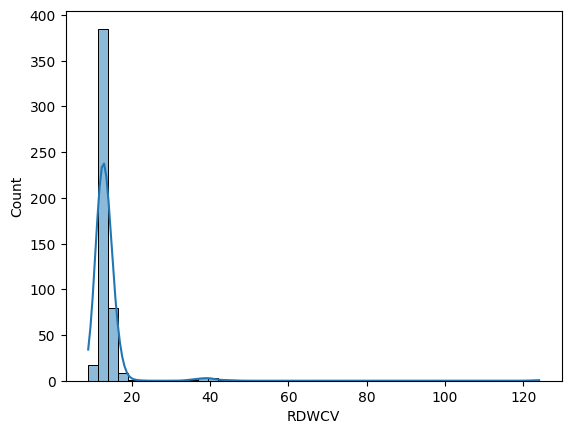

In [31]:
sns.histplot(x='RDWCV',data=df,kde=True)

<Axes: xlabel='RDWCV'>

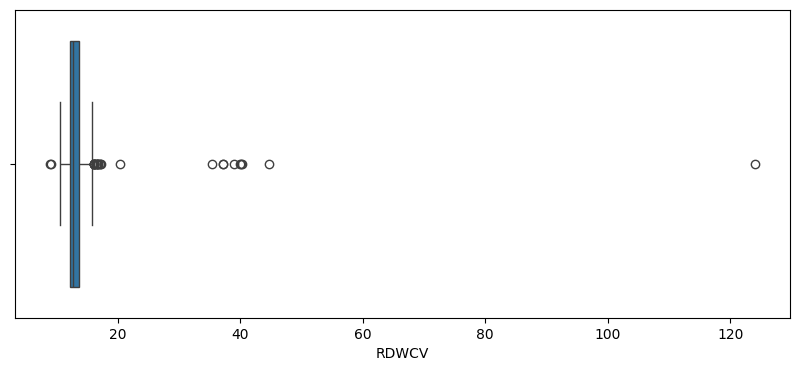

In [32]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['RDWCV'])

### Hemoglobin (HGB)

In [33]:
df['HGB'].describe()

count    500.000000
mean      11.740020
std        5.628807
min      -10.000000
25%        9.900000
50%       11.500000
75%       13.100000
max       87.100000
Name: HGB, dtype: float64

<Axes: xlabel='HGB', ylabel='Density'>

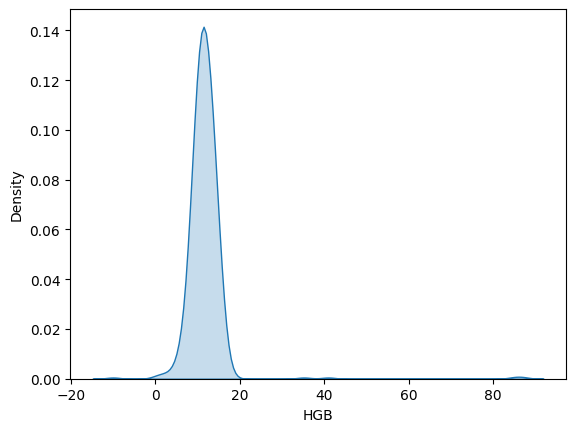

In [80]:
sns.kdeplot(df['HGB'],fill=True)

<Axes: xlabel='HGB'>

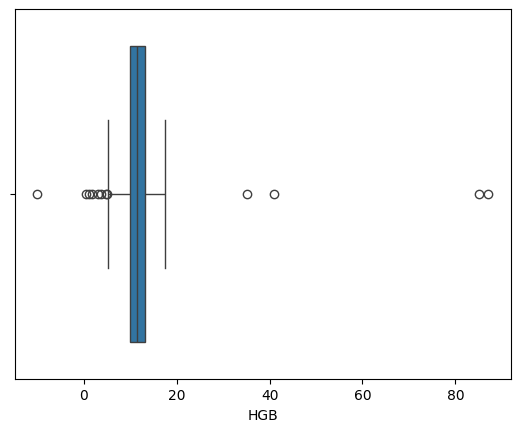

In [35]:
sns.boxplot(x=df['HGB'])

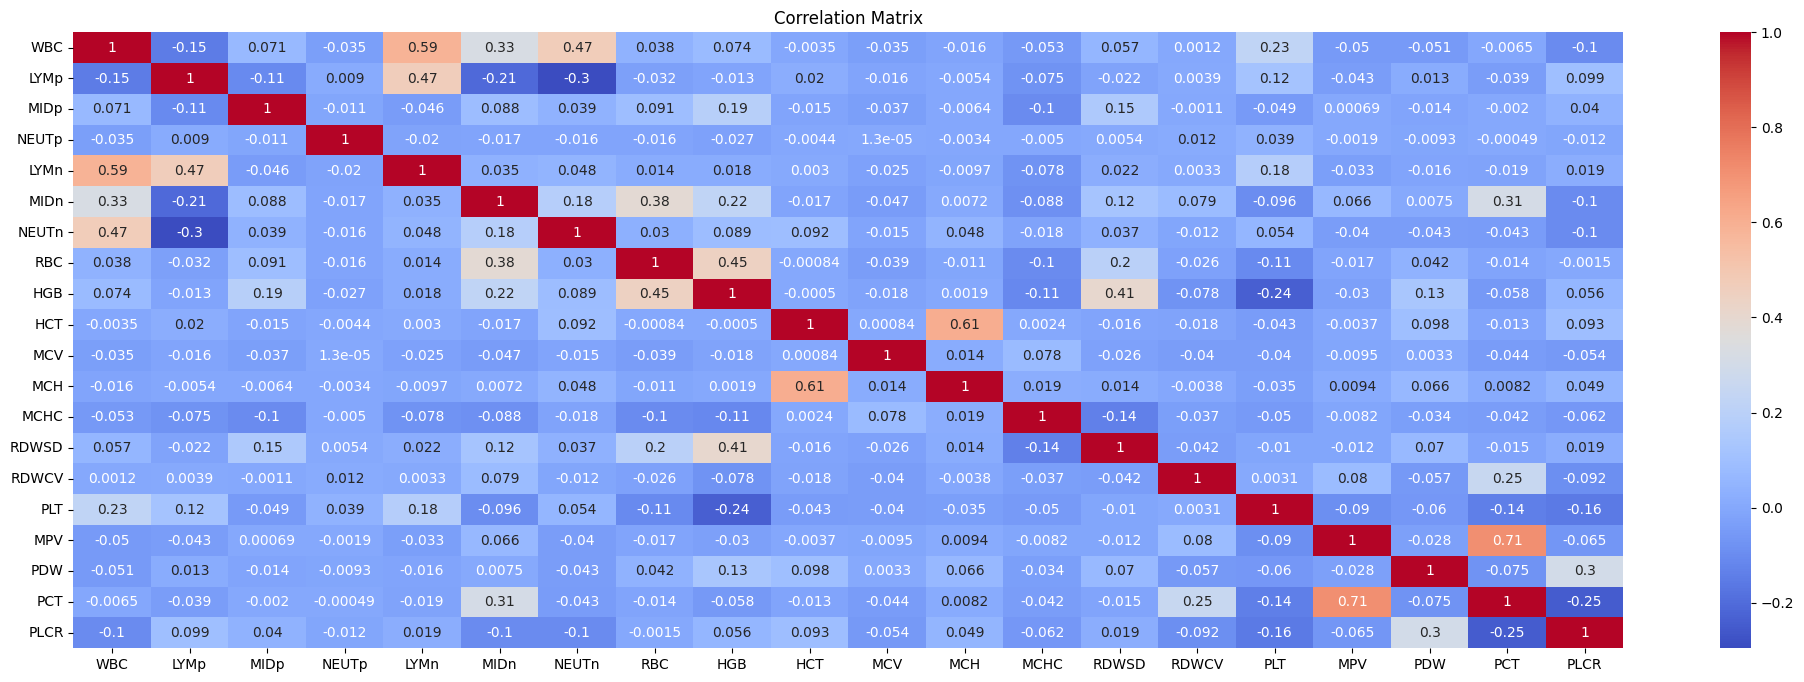

In [36]:
corr = df.corr()

plt.figure(figsize=(25,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
(df<0).sum()

ID       0
WBC      0
LYMp     0
MIDp     0
NEUTp    0
LYMn     0
MIDn     0
NEUTn    0
RBC      0
HGB      1
HCT      0
MCV      1
MCH      0
MCHC     0
RDWSD    0
RDWCV    0
PLT      0
MPV      0
PDW      0
PCT      0
PLCR     0
dtype: int64

In [ ]:
df=df[df>0]

In [ ]:
(df<0).sum()

ID       0
WBC      0
LYMp     0
MIDp     0
NEUTp    0
LYMn     0
MIDn     0
NEUTn    0
RBC      0
HGB      0
HCT      0
MCV      0
MCH      0
MCHC     0
RDWSD    0
RDWCV    0
PLT      0
MPV      0
PDW      0
PCT      0
PLCR     0
dtype: int64

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

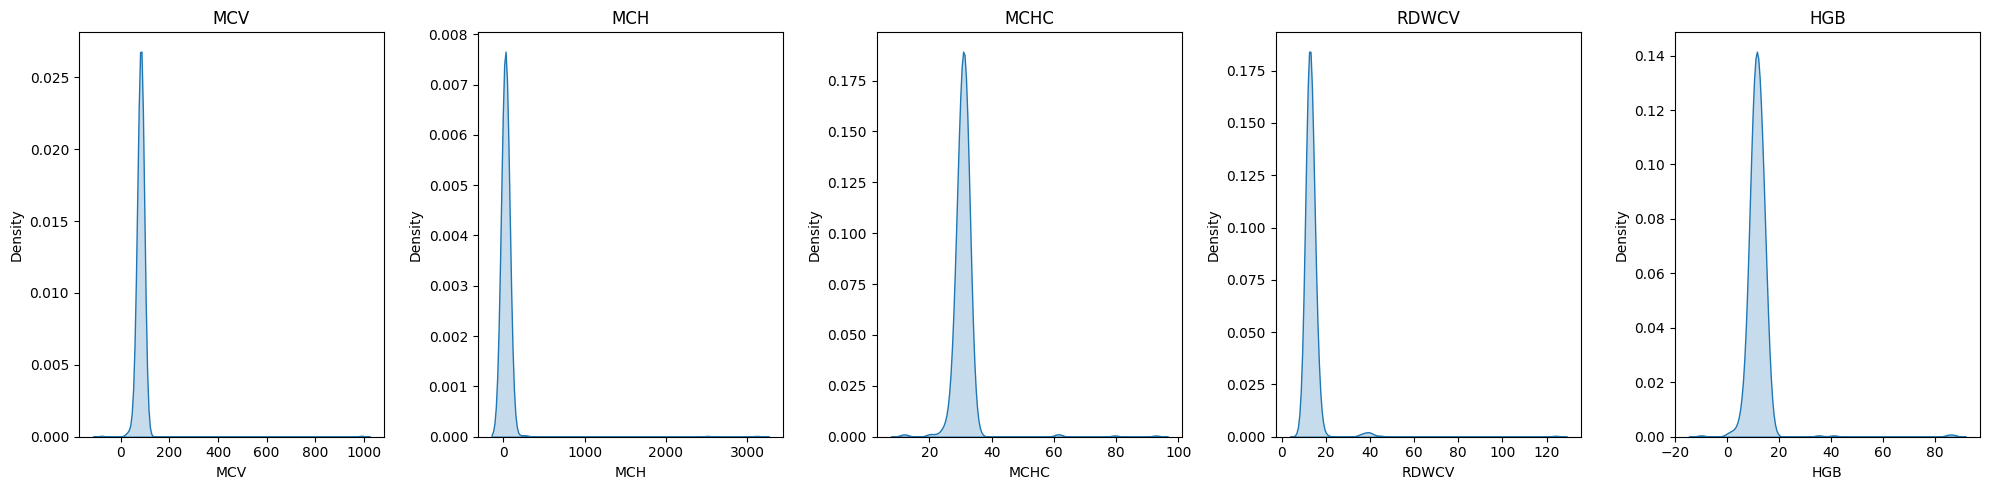

In [91]:
features = ['MCV','MCH','MCHC','RDWCV','HGB']

fig, ax = plt.subplots(1,5, figsize=(20,5))

for i, feature in enumerate(features):
    sns.kdeplot(df[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

In [94]:
features = ['MCV','MCH','MCHC','RDWCV','HGB']

for feature in features:
    print(feature, df[feature].skew())

MCV 19.727262936101184
MCH 15.858274097992192
MCHC 8.170162468273327
RDWCV 13.253836545300775
HGB 9.510592029791304


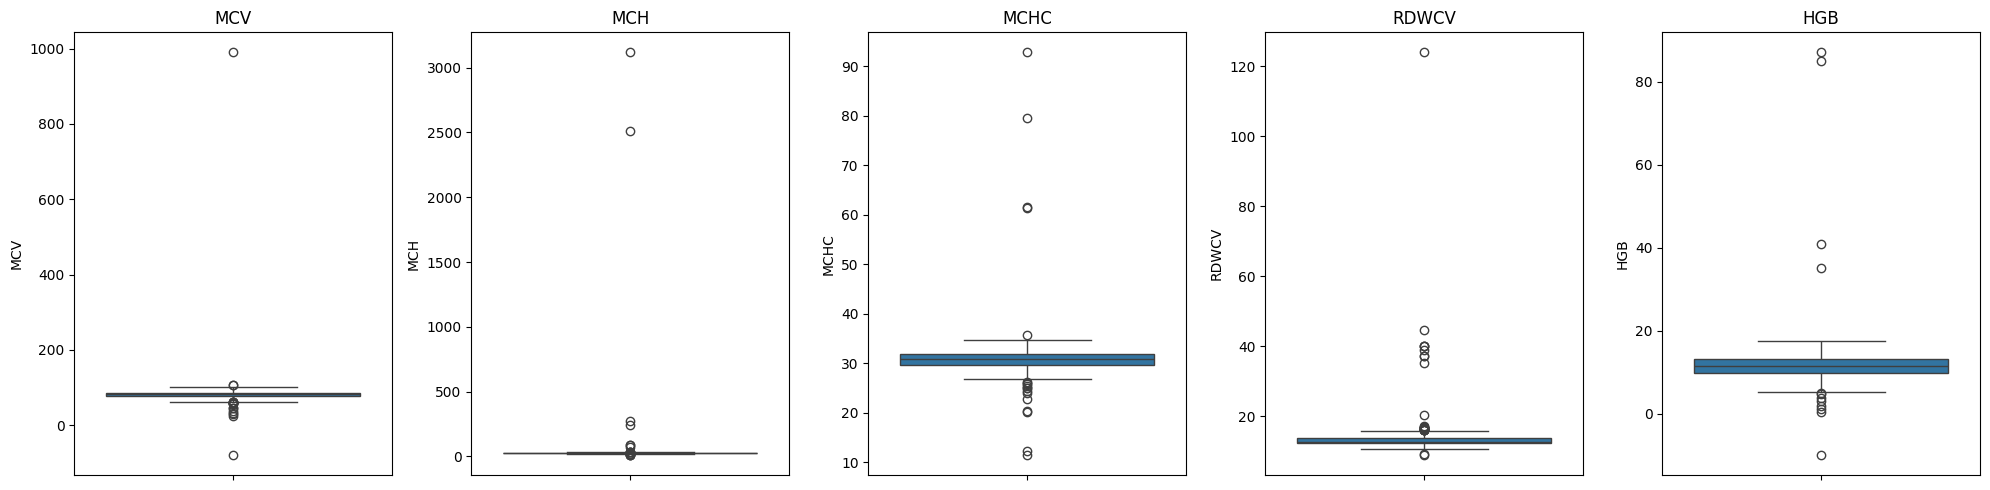

In [95]:
features = ['MCV','MCH','MCHC','RDWCV','HGB']

fig, ax = plt.subplots(1,5, figsize=(20,5))

for i, feature in enumerate(features):
    sns.boxplot(df[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()

In [96]:
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR



In [98]:
df_clean = df.copy()

for col in features:
    
    df_clean[col] = np.where(
        df_clean[col] < lower[col], lower[col],
        np.where(df_clean[col] > upper[col], upper[col], df_clean[col])
    )

In [99]:
print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original shape: (500, 20)
After removing outliers: (500, 20)


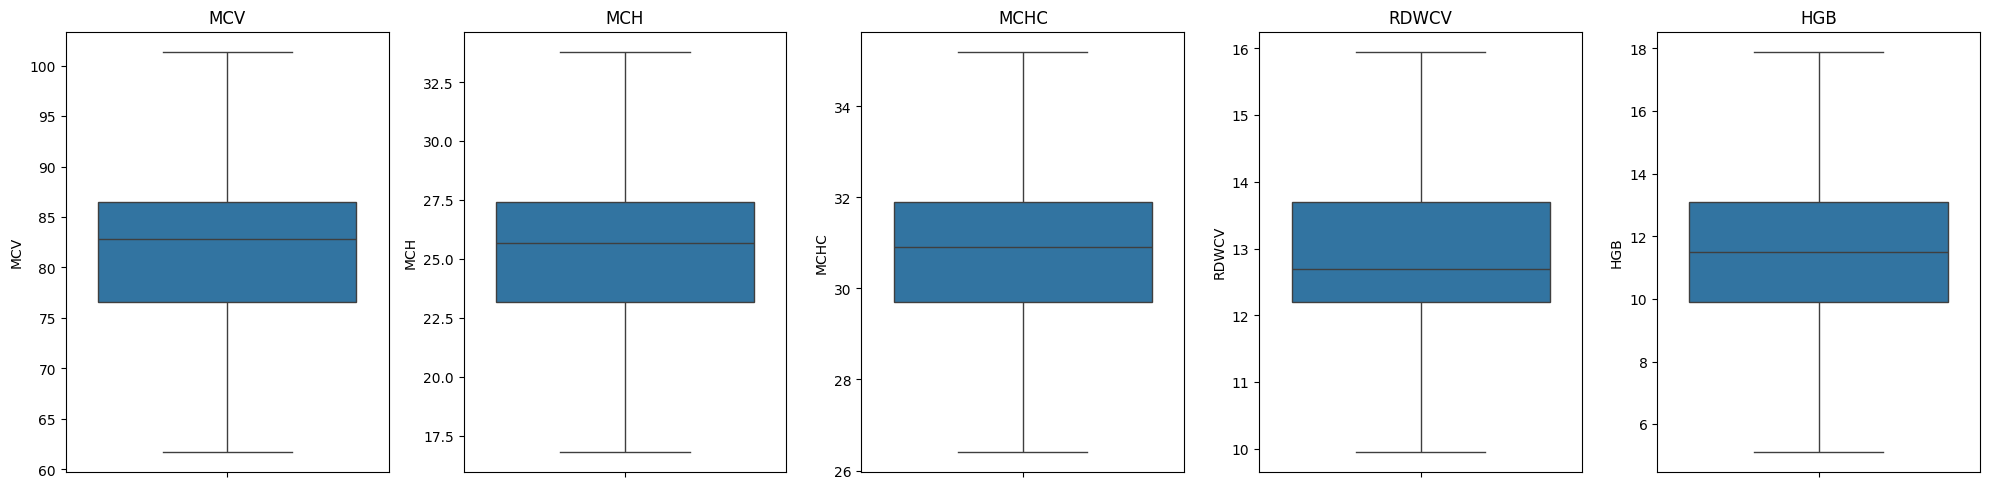

In [101]:
features = ['MCV','MCH','MCHC','RDWCV','HGB']

fig, ax = plt.subplots(1,5, figsize=(20,5))

for i, feature in enumerate(features):
    sns.boxplot(df_clean[feature], ax=ax[i], fill=True)
    ax[i].set_title(feature)

plt.tight_layout()
plt.show()


In [77]:
MCV_ref=90
MCH_ref=30
MCHC_ref=34
RDW_ref=13
HGB_ref=14

In [78]:
D_MCV = np.maximum((MCV_ref - df_clean['MCV']) / MCV_ref, 0)
D_MCH = np.maximum((MCH_ref - df_clean['MCH']) / MCH_ref, 0)
D_MCHC = np.maximum((MCHC_ref - df_clean['MCHC']) / MCHC_ref, 0)
D_RDW = np.maximum((df_clean['RDWCV'] - RDW_ref) / RDW_ref, 0)
D_HGB = np.maximum((HGB_ref - df_clean['HGB']) / HGB_ref, 0)

In [79]:
df_clean["Severity"] = (
    0.25 * D_MCV +
    0.20 * D_MCH +
    0.20 * D_MCHC +
    0.15 * D_RDW +
    0.20 * D_HGB
)

In [80]:
df_clean.head()

,WBC,LYMp,MIDp,NEUTp,LYMn,MIDn,NEUTn,RBC,HGB,HCT,...,MCH,MCHC,RDWSD,RDWCV,PLT,MPV,PDW,PCT,PLCR,Severity
0,10.0,43.2,6.7,50.1,4.3,0.7,5.0,2.77,7.3,24.2,...,26.3,30.1,35.3,11.40,189.0,9.2,12.5,0.17,22.3,0.149711
1,10.0,42.4,5.3,52.3,4.2,0.5,5.3,2.84,7.3,25.0,...,25.7,26.4,35.3,11.40,180.0,8.9,12.5,0.16,19.5,0.174087
2,7.2,30.7,8.6,60.7,2.2,0.6,4.4,3.97,9.0,30.5,...,22.6,29.5,37.2,13.70,148.0,10.1,14.3,0.14,30.5,0.191421
3,6.0,30.2,6.3,63.5,1.8,0.4,3.8,4.22,5.1,32.8,...,23.2,29.8,46.5,15.95,143.0,8.6,11.3,0.12,16.4,0.264832
4,4.2,39.1,7.2,53.7,1.6,0.3,2.3,3.93,5.1,316.0,...,23.9,29.7,42.7,15.10,236.0,19.5,12.8,0.22,24.8,0.243446


In [81]:
df_clean['Severity'].describe()

count    500.000000
mean       0.122345
std        0.077358
min        0.000000
25%        0.062428
50%        0.106859
75%        0.168526
max        0.366387
Name: Severity, dtype: float64

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
X=df_clean[['MCV','MCH','MCHC','RDWCV','HGB']]
Y=df_clean['Severity']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [84]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((400, 5), (100, 5), (400,), (100,))

In [85]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [86]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [87]:
np.round(X_train_scaled.describe(),1)

,MCV,MCH,MCHC,RDWCV,HGB
count,400.0,400.0,400.0,400.0,400.0
mean,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0
min,-2.5,-2.5,-2.5,-2.5,-2.7
25%,-0.6,-0.6,-0.6,-0.7,-0.7
50%,0.3,0.2,0.1,-0.3,0.0
75%,0.7,0.7,0.7,0.5,0.7
max,2.6,2.6,2.6,2.3,2.7


In [90]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, Y_train)

y_pred = model.predict(X_test_scaled)

In [91]:
y_pred

array([ 0.17116599,  0.27130434,  0.02524554,  0.18149525,  0.22136655,
        0.23224769,  0.10415143,  0.31474148,  0.10671634,  0.03581366,
        0.07340608,  0.07347958,  0.2561026 ,  0.03918419,  0.25771861,
        0.15156252,  0.05760587,  0.08625454,  0.11737156,  0.08625454,
        0.07042757,  0.25442928,  0.12135826,  0.00414593,  0.20333613,
        0.04985815,  0.15398901,  0.14832492,  0.08104599,  0.15148226,
        0.15420807,  0.08243288,  0.09115344,  0.0191121 ,  0.19234205,
        0.0561266 ,  0.11253363,  0.08862742,  0.05634159,  0.20543028,
        0.28883787,  0.11010777,  0.14995586,  0.08417917,  0.12653522,
        0.20093569,  0.13679924,  0.1157171 ,  0.2356213 ,  0.06409523,
        0.27426258,  0.17153724,  0.19322167,  0.11125435,  0.23604525,
        0.10919695,  0.09873327,  0.06207961,  0.10801858, -0.00075559,
        0.19344983,  0.11503794,  0.1447115 ,  0.19624927,  0.01526386,
        0.09952547,  0.05215666,  0.29144105,  0.2419652 ,  0.16